<a href="https://colab.research.google.com/github/akasharora00/Awaaz/blob/main/Titanic_Outrix.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Titanic Survival Prediction

## Machine Learning Classification Project

### Objective
Predict whether a passenger survived the Titanic disaster using demographic and travel-related information by applying Machine Learning classification algorithms.

## Objective

The aim of this project is to:

- Load the Titanic dataset.
- Perform data preprocessing.
- Handle missing values.
- Convert categorical features into numerical values.
- Train Machine Learning models.
- Compare Logistic Regression and Decision Tree classifiers.
- Evaluate model performance using accuracy and confusion matrix.


## import liberaries

In [ ]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier

from sklearn.metrics import accuracy_score, confusion_matrix

## Load Dataset

In [ ]:
df = pd.read_csv("Titanic-Dataset.csv")

## Load Dataset

In [ ]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [ ]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


# Data Cleaning

## Handle Missing Values


In [ ]:
df["Age"] = df["Age"].fillna(df["Age"].median())

In [ ]:
df["Embarked"] = df["Embarked"].fillna(df["Embarked"].mode()[0])

In [ ]:
df.drop("Cabin", axis=1, inplace=True)

In [ ]:
df.drop(["PassengerId","Name","Ticket"], axis=1, inplace=True)

In [ ]:
df["Sex"] = df["Sex"].map({
      "male":0,
      "female":1
})

In [ ]:
df = pd.get_dummies(df, columns=["Embarked"], drop_first=True)

# Visualisation

## Exploratory Data Analysis (EDA)

## Survival Distribution

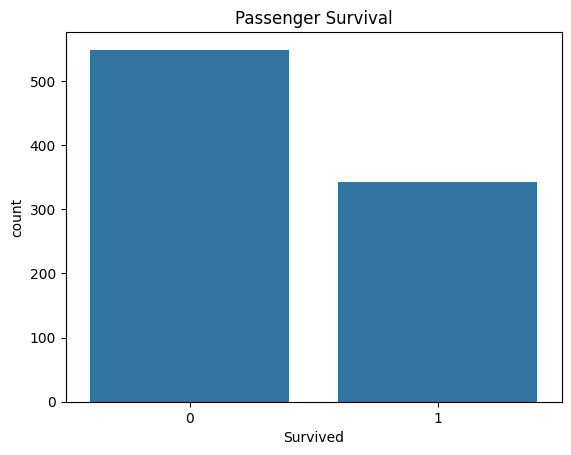

In [ ]:
sns.countplot(x="Survived", data=df)

plt.title("Passenger Survival")

plt.show()

## Survival Distribution

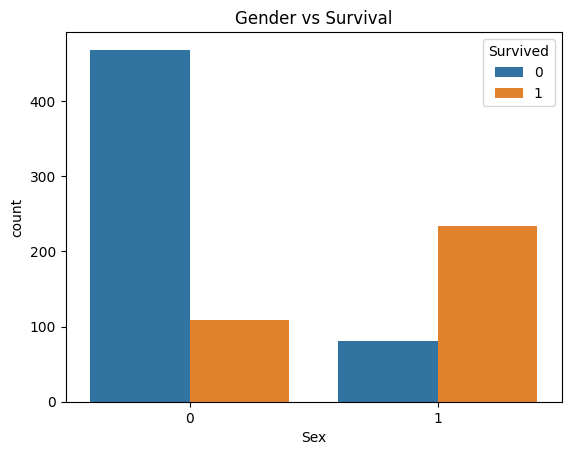

In [ ]:
sns.countplot(x="Sex", hue="Survived", data=df)
plt.title("Gender vs Survival")
plt.show()

## Passenger Class vs Survival

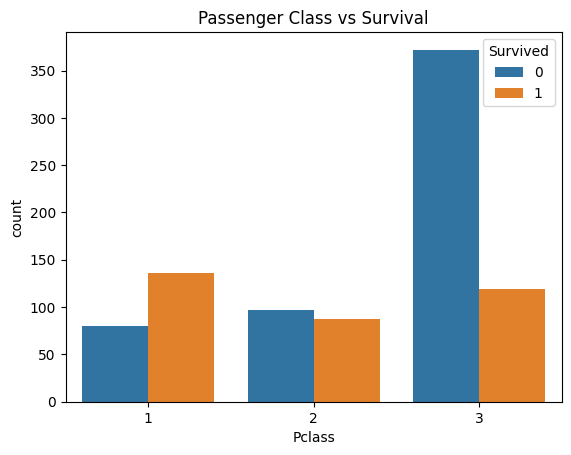

In [ ]:
sns.countplot(x="Pclass", hue="Survived", data=df)
plt.title("Passenger Class vs Survival")
plt.show()

Age Distribution

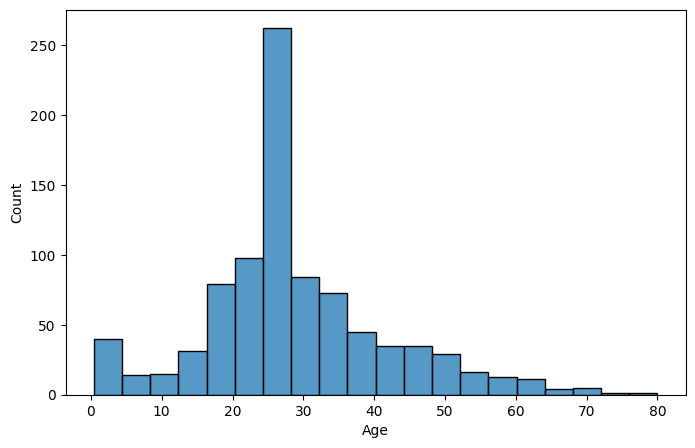

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(df["Age"], bins=20)

plt.show()

## Feature Engineering

In [ ]:
X = df.drop("Survived", axis=1)

y = df["Survived"]

## Train-Test Split

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(
      X,
          y,
              test_size=0.2,
                  random_state=42
                  )

## Logistic Regression Model

In [ ]:
lr = LogisticRegression(max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(max_iter=1000)

In [ ]:
lr_pred = lr.predict(X_test)

In [ ]:
print("Logistic Regression Accuracy:")

print(accuracy_score(y_test, lr_pred))

Logistic Regression Accuracy:
0.8100558659217877


## Decision Tree Model

In [ ]:
dt = DecisionTreeClassifier(random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(random_state=42)

In [ ]:
dt_pred = dt.predict(X_test)

## Model Comparison

In [ ]:
print("Decision Tree Accuracy:")

print(accuracy_score(y_test, dt_pred))


Decision Tree Accuracy:
0.7877094972067039


In [ ]:
print("Logistic Regression:", accuracy_score(y_test, lr_pred))

print("Decision Tree:", accuracy_score(y_test, dt_pred))

Logistic Regression: 0.8100558659217877
Decision Tree: 0.7877094972067039


## Confusion Matrix

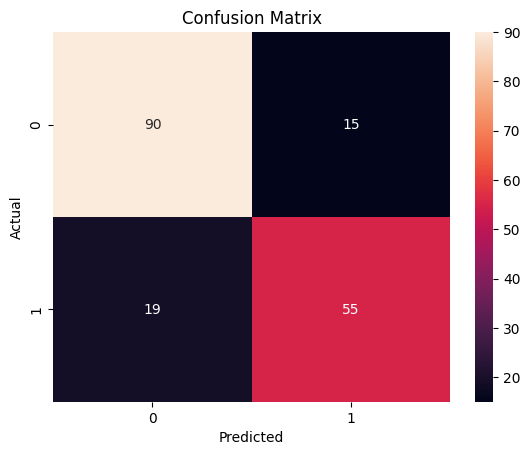

In [ ]:
cm = confusion_matrix(y_test, lr_pred)

sns.heatmap(cm, annot=True, fmt="d")

plt.xlabel("Predicted")

plt.ylabel("Actual")

plt.title("Confusion Matrix")

plt.show()

## Conclusion

- Successfully loaded and explored the Titanic dataset.
- Handled missing values and removed unnecessary columns.
- Converted categorical variables into numerical form.
- Trained Logistic Regression and Decision Tree models.
- Compared the performance of both models using accuracy.
- Evaluated the model using a confusion matrix.
- Logistic Regression achieved better performance for this dataset (if its accuracy is higher), making it the preferred model for predicting passenger survival.